In [1]:
from sympy import Function, symbols

a, b, c, z = symbols("a b c z")

f = Function("f")
g = Function("g")
phi = Function("phi")

In [2]:
from sympy import diff, dsolve

result = dsolve(2 * diff(phi(z), z) + (c - (a + b + 1) * z) / z / (1 - z), phi(z))

In [3]:
result.rhs

C1 - c*log(z)/2 - (a + b - c + 1)*log(z - 1)/2

In [4]:
from sympy import simplify

expr = (
    z * (1 - z) * (diff(phi(z), z, z) + diff(phi(z), z) ** 2)
    + diff(phi(z), z) * (c - (a + b + 1) * z)
    - a * b
)
simplify(expr.subs(phi(z), result.rhs).doit()).factor()

(a**2*z**2 - 2*a*b*z**2 + 4*a*b*z - 2*a*c*z + b**2*z**2 - 2*b*c*z + c**2 + 2*c*z - 2*c - z**2)/(4*z*(z - 1))

In [5]:
from sympy import exp

hypergeom = (
    diff(f(z), z, z)
    + (c - (a + b + 1) * z) / z / (1 - z) * diff(f(z), z)
    - a * b * f(z) / z / (1 - z)
)
diffterm = hypergeom.subs(f(z), exp(phi(z)) * g(z)).doit().expand().coeff(
    diff(g(z), z)
) / exp(phi(z))
simplify(diffterm)

(a*z + b*z - c + 2*z*(z - 1)*Derivative(phi(z), z) + z)/(z*(z - 1))

In [6]:
hypergeom

-a*b*f(z)/(z*(1 - z)) + Derivative(f(z), (z, 2)) + (c - z*(a + b + 1))*Derivative(f(z), z)/(z*(1 - z))

In [7]:
result = dsolve(diffterm, phi(z))
result.rhs

C1 - c*log(z)/2 - (a + b - c + 1)*log(z - 1)/2

In [8]:
expr2 = simplify(
    hypergeom.subs(f(z), exp(result.rhs) * g(z)).doit() / exp(result.rhs)
).expand()
expr2

-a**2*z**2*g(z)/(4*z**4 - 8*z**3 + 4*z**2) + 2*a*b*z**2*g(z)/(4*z**4 - 8*z**3 + 4*z**2) - 4*a*b*z*g(z)/(4*z**4 - 8*z**3 + 4*z**2) + 2*a*c*z*g(z)/(4*z**4 - 8*z**3 + 4*z**2) - b**2*z**2*g(z)/(4*z**4 - 8*z**3 + 4*z**2) + 2*b*c*z*g(z)/(4*z**4 - 8*z**3 + 4*z**2) - c**2*g(z)/(4*z**4 - 8*z**3 + 4*z**2) - 2*c*z*g(z)/(4*z**4 - 8*z**3 + 4*z**2) + 2*c*g(z)/(4*z**4 - 8*z**3 + 4*z**2) + 4*z**4*Derivative(g(z), (z, 2))/(4*z**4 - 8*z**3 + 4*z**2) - 8*z**3*Derivative(g(z), (z, 2))/(4*z**4 - 8*z**3 + 4*z**2) + z**2*g(z)/(4*z**4 - 8*z**3 + 4*z**2) + 4*z**2*Derivative(g(z), (z, 2))/(4*z**4 - 8*z**3 + 4*z**2)

In [9]:
simplify(expr2.coeff(diff(g(z), z, z)))

1

In [10]:
from sympy import fraction

simplify(expr2.coeff(g(z))).factor()
num, denom = fraction(_)
num

1

In [11]:
denom

1

In [12]:
num.collect(z)

1

In [13]:
num.collect(a)

1

In [14]:
num.collect(c)

1

In [ ]:
from sympy import Eq, Rational, hyper, oo, real_root, solve

w = symbols("w")


def get_soln(sg1, sg2, sg3, exp_pt):
    a, b, c = symbols("a b c")
    eq1 = Eq(c - a - b, sg1 * Rational(1, 2))
    eq2 = Eq(1 - c, sg2 * Rational(1, 3))
    eq3 = Eq(a - b, sg3 * Rational(1, 5))
    solns = solve([eq1, eq2, eq3], [a, b, c])
    a = solns[a]
    b = solns[b]
    c = solns[c]
    coeff = 1 / real_root(1728, 5)
    print(a, b, c)
    if exp_pt == 0:
        return (
            lambda z: coeff
            * hyper([a, b], [c], z)
            / (z ** (1 - c) * hyper([1 + a - c, 1 + b - c], [2 - c], z))
        )
    elif exp_pt == 1:
        num = lambda z: hyper([a, b], [1 + a + b - c], 1 - z)
        denom = lambda z: (1 - z) ** (c - a - b) * hyper(
            [c - a, c - b], [1 + c - a - b], 1 - z
        )
        return lambda z: coeff * num(z) / denom(z)
    elif exp_pt == oo:
        num = lambda z: z ** (-a) * hyper([a, 1 + a - c], [1 + a - b], 1 / z)
        denom = lambda z: z ** (-b) * hyper([b, 1 + b - c], [1 + b - a], 1 / z)
        return lambda z: coeff * num(z) / denom(z)
        # if z == oo:
        #     num = lambda w: (1 / w) ** (-a) * hyper([a, 1 + a - c], [1 + a - b], w)
        #     denom = lambda w: (1 / w) ** (-b) * hyper([b, 1 + b - c], [1 + b - a], w)
        #     return lambda z: coeff * limit(num(w) / denom(w), w, 1 / z)
        # elif z == 0:
        #     print("here")
        #     num = lambda z: z ** (-a) * hyper([a, 1 + a - c], [1 + a - b], 1 / z)
        #     denom = lambda z: z ** (-b) * hyper([b, 1 + b - c], [1 + b - a], 1 / z)
        #     return lambda z: coeff * limit(num(z) / denom(z), z, 0, dir="-")
        # else:
        #     num = lambda z: z ** (-a) * hyper([a, 1 + a - c], [1 + a - b], 1 / z)
        #     denom = lambda z: z ** (-b) * hyper([b, 1 + b - c], [1 + b - a], 1 / z)
        #     return lambda z: coeff * num(z) / denom(z)


get_soln(1, 1, 1, oo)(1).evalf()

11/60 -1/60 2/3


0.284079043840412

In [16]:
get_soln(1, 1, 1, oo)(-0.0000001).evalf()

0.273111953772192 - 0.198427449322131*I

In [17]:
from itertools import product

for s1, s2, s3, exp_pt in product([+1, -1], [+1, -1], [+1, -1], [0, 1, oo]):
    print(f"{s1, s2, s3, exp_pt}: {get_soln(s1, s2, s3, exp_pt)(-1e-15 * I).evalf()}")

NameError: name 'I' is not defined

In [ ]:
for s1, s2, s3 in product([+1, -1], [+1, -1], [+1, -1]):
    print(f"{s1, s2, s3}: {get_soln(s1, s2, s3, 0)(0).evalf()}")

(1, 1, 1): zoo
(1, 1, -1): zoo
(1, -1, 1): 0
(1, -1, -1): 0
(-1, 1, 1): zoo
(-1, 1, -1): zoo
(-1, -1, 1): 0
(-1, -1, -1): 0


In [ ]:
for s1, s2, s3 in product([+1, -1], [+1, -1], [+1, -1]):
    print(f"{s1, s2, s3}: {get_soln(s1, s2, s3, 1)(1).evalf()}")

(1, 1, 1): zoo
(1, 1, -1): zoo
(1, -1, 1): zoo
(1, -1, -1): zoo
(-1, 1, 1): 0
(-1, 1, -1): 0
(-1, -1, 1): 0
(-1, -1, -1): 0


In [ ]:
for s1, s2, s3 in product([+1, -1], [+1, -1], [+1, -1]):
    print(
        f"{s1, s2, s3}: {get_soln(s1, s2, s3, oo)(-1e-15).doit().evalf()}, {get_soln(s1, s2, s3, oo)(1).evalf()}, {get_soln(s1, s2, s3, oo)(1e55).evalf()}"
    )

(1, 1, 1): 0.273657890659636 - 0.198824095688466*I, 0.284079043840412, 2.25160006420103E-12
(1, 1, -1): 0.121252253496504 + 0.0880949187816968*I, 0.178460993833747, 22516000642.0102
(1, -1, 1): 0.273657890659637 - 0.198824095688467*I, 0.284079043840412, 2.25160006420100E-12
(1, -1, -1): 0.121252253496504 + 0.0880949187816966*I, 0.178460993833747, 22516000642.0104
(-1, 1, 1): 0.273657890659636 - 0.198824095688467*I, oo, 2.25160006420102E-12
(-1, 1, -1): 0.121252253496504 + 0.0880949187816967*I, oo, 22516000642.0103
(-1, -1, 1): 0.273657890659636 - 0.198824095688466*I, oo, 2.25160006420103E-12
(-1, -1, -1): 0.121252253496504 + 0.0880949187816969*I, oo, 22516000642.0101


In [ ]:
get_soln(1, 1, 1, oo)(1).evalf()

0.284079043840412

complex128


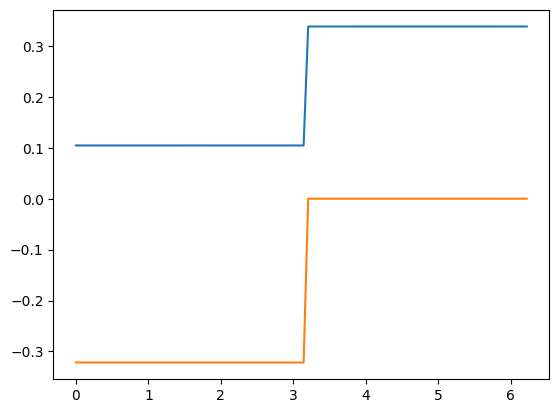

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from sympy import I, pi

thetas = np.linspace(0, 2 * pi, 100, endpoint=False)
vals = []
for theta in thetas:
    val = (
        get_soln(1, 1, 1, oo)(0.00000000001 * exp(I * theta)) * exp(-I * pi / 5)
    ).evalf()
    # print(val)
    if val is not None:
        vals.append(val)
vals = np.array(vals, dtype=np.complex128)
print(vals.dtype)
plt.plot(thetas, np.real(vals))
plt.plot(thetas, np.imag(vals))
plt.show()

In [293]:
import numpy as np
from scipy.special import hyp2f1


def s_inv(Z, sg1=+1, sg2=+1, sg3=+1):
    a, b, c = symbols("a b c")
    eq1 = Eq(c - a - b, sg1 * Rational(1, 2))
    eq2 = Eq(1 - c, sg2 * Rational(1, 3))
    eq3 = Eq(a - b, sg3 * Rational(1, 5))
    solns = solve([eq1, eq2, eq3], [a, b, c])
    a = float(solns[a])
    b = float(solns[b])
    c = float(solns[c])
    # a, b, c = 11 / 60, -1 / 60, 2 / 3
    num = Z ** (-a) * hyp2f1(a, 1 + a - c, 1 + a - b, 1 / Z)
    denom = Z ** (-b) * hyp2f1(b, 1 + b - c, 1 + b - a, 1 / Z)
    # print(num,denom)
    coeff = sg3 / (1728) ** (sg3 / 5)
    # coeff = 1
    # coeff = -3.5201470213402 / 0.7925963259246634
    return coeff * np.divide(num, denom)


s_inv(np.array([-1e-55j])) * np.exp(-np.pi / 5 * 1j)

array([0.33826121-2.50388975e-17j])

In [294]:
from sympy import I, exp, pi

(get_soln(1, 1, 1, oo)(-1e-55 * I) * exp(-I * pi / 5)).evalf()

11/60 -1/60 2/3


0.338261212717716 - 3.3881317890172e-20*I

In [295]:
-((3.5201470213402 / 0.7925963259246634) ** 5)

-1727.9999999999964

## The Icosahedral Equation

By now, it should be clear that &mdash; given an arbitrary quintic equation
&mdash; it's possible to massage this quintic into a form that can be used to 

If the expansion point is $Z\to\infty$ then we find that first two signs
$\sigma_1$, $\sigma_2$ do not change the resulting expression, but that the sign $\sigma_3$ dictates whether $s(Z \to \infty)$ approaches either 0 ($\sigma_3=+1$) or $\infty$ ($\sigma_3=-1$):

$$

s(Z) = \frac{\sigma_3}{(1728)^{\tfrac{\sigma_3}5}} \frac{Z^{-a}\, {}_2F_1(a, 1+a-c; 1+a-b; 1/Z)}{Z^{-b}\,{}_2F_1(b,1+b-c;1+b-a;1/Z)}

$$

As we approach the singular points 0, 1, $\infty$ from above/below the real axis, we find the following:

$$

\quad S(Z \to \infty) = \begin{cases}
0 &\,,\quad \sigma_3 = +1 \\
\infty &\,,\quad \sigma_3 = -1

\end{cases}\,.

$$

Similarly, the other two singular points are found to be

$$

S(0\pm i\epsilon) = \sigma_3\,(h_1\,e^{\mp i\pi/5})^{\sigma_3} \,,\quad S(1\pm i\epsilon) = z_n -\sigma_3\, j \,,

$$

where $h_1 := [(1-k)z_n-1]/2 \simeq 0.33826\ldots$, and where $\epsilon >0$ and
$\pm$ dictates whether the singular point is approached from above/below. Since
the values in the above with $\sigma_3 = +1$ are antipodal to those with
$\sigma_3 = -1$ (and since $z=0$ is antipodal to $z\to\infty$), we find that
this sign determines whether the triangle under consideration lies either at the
top or the bottom of the Riemann sphere. Lastly, the upper/lower half-planes
must describe the mirror image of the fundamental triangle in the $\xi$-axis,
since the vertex and midpoint do not move, as they are real, and the face centre
goes from rotated up by $e^{i\pi/5}$ to rotated down by the same amount. 

In [ ]:
1 / 0.3382617

2.9562909427818758

In [310]:
from itertools import product

eps = 1e-55j

for s1, s2, s3 in product([+1, -1], [+1, -1], [+1, -1]):
    print(
        s1,
        s2,
        s3,
        "F:",
        s_inv(eps, sg1=s1, sg2=s2, sg3=s3) * np.exp(-np.pi / 5 * 1j),
        s_inv(eps, sg1=s1, sg2=s2, sg3=s3) * np.exp(+np.pi / 5 * 1j),
        "E:",
        s_inv(1 + eps, sg1=s1, sg2=s2, sg3=s3),
        "V:",
        s_inv(1e55 + eps, sg1=s1, sg2=s2, sg3=s3),
        s_inv(-3 - 5j),
        s_inv(-3 + 5j),
    )

1 1 1 F: (0.1045284632676535-0.3217055305650853j) (0.3382612127177165+2.0165837040625896e-17j) E: (0.2840790438404124-2.0862790179196747e-29j) V: (2.251600064201026e-12-4.503200128402052e-123j) (0.14244767294577834+0.06602319464811653j) (0.14244767294577834-0.06602319464811653j)
1 1 -1 F: (-2.9562952014676105-5.875776049326388e-17j) (-0.9135454576426009-2.811603815447865j) E: (-3.520147021340201-2.585199095058965e-28j) V: (-444128606984.5832-8.882572139691663e-100j) (0.14244767294577834+0.06602319464811653j) (0.14244767294577834-0.06602319464811653j)
1 -1 1 F: (0.10452846326765503-0.32170553056508994j) (0.3382612127177213+3.3086219180672475e-17j) E: (0.2840790438404122-2.0862790179196752e-29j) V: (2.2516000642010035e-12-4.503200128402008e-123j) (0.14244767294577834+0.06602319464811653j) (0.14244767294577834-0.06602319464811653j)
1 -1 -1 F: (-2.9562952014675687+3.0909058052619345e-16j) (-0.9135454576425882-2.811603815447825j) E: (-3.520147021340202-2.5851990950589683e-28j) V: (-44412860

In [ ]:
s_inv(-3 - 5j)

np.complex128(0.14244767294577834+0.06602319464811653j)

In [273]:
import numpy as np


def s_inv2(Z, sg1=+1, sg2=+1, sg3=+1):
    a, b, c = symbols("a b c")
    eq1 = Eq(c - a - b, sg1 * Rational(1, 2))
    eq2 = Eq(1 - c, sg2 * Rational(1, 3))
    eq3 = Eq(a - b, sg3 * Rational(1, 5))
    solns = solve([eq1, eq2, eq3], [a, b, c])
    a = float(solns[a])
    b = float(solns[b])
    c = float(solns[c])
    # a, b, c = 11 / 60, -1 / 60, 2 / 3
    num = hyp2f1(a, b, c, Z)
    denom = Z ** (1 - c) * hyp2f1(1 + a - c, 1 + b - c, 2 - c, Z)
    # print(num,denom)
    coeff = 1  # (1728) ** (1 / 5)
    # coeff = 0.284079041754133/0.70882405176421
    # coeff = 0.284079041754133 / 1.4107873420929684
    coeff = 0.338261212717716 / 2.586766338312561
    # coeff = 0.338261212717716 / 0.18448308813935999
    return coeff * np.divide(num, denom)


s_inv2(np.array([-1e-55j]))

array([2.43982662e+17+1.40863456e+17j])

In [274]:
(2.586766338312561 / 0.338261212717716) ** 6

199999.99999279383

In [275]:
0.338261212717716 / 2.586766338312561, 1 / (200000) ** (1 / 6)

(0.13076604860196833, 0.13076604860118307)

In [276]:
(0.284079043840412 / 1.4107873573583158)

0.20136205669743665

In [277]:
(0.338261212717716 / 0.18448308813935999) ** 6

37.99914721467943

In [278]:
from itertools import product

eps = -1e-55j

for s1, s2, s3 in product([+1, -1], [+1, -1], [+1, -1]):
    print(
        s1,
        s2,
        s3,
        "F:",
        s_inv2(eps, sg1=s1, sg2=s2, sg3=s3),
        "E:",
        s_inv2(1 + eps, sg1=s1, sg2=s2, sg3=s3),
        "V:",
        s_inv2(1e55 + eps, sg1=s1, sg2=s2, sg3=s3) * np.exp(-np.pi / 3 * 1j),
        s_inv2(1e55 + eps, sg1=s1, sg2=s2, sg3=s3) * np.exp(+np.pi / 3 * 1j),
    )

1 1 1 F: (2.4398266219041667e+17+1.4086345569323858e+17j) E: (0.09269011940029458+1.0029483789626555e-29j) V: (0.05055193685846039-2.2042011928602662e-13j) (-0.0252759684290393+0.04377926153004382j)
1 1 -1 F: (2.4398266219041667e+17+1.4086345569323858e+17j) E: (0.09269011940029454+1.002948378962655e-29j) V: (0.05055193685846039-2.2042011928602662e-13j) (-0.0252759684290393+0.04377926153004382j)
1 -1 1 F: (5.256447111893667e-20-3.034811155032838e-20j) E: (0.18448308813935999-1.99618918815216e-29j) V: (-0.16913060635758062-0.2929428033292114j) (0.33826121271771603+1.474920100812128e-12j)
1 -1 -1 F: (5.256447111893667e-20-3.034811155032838e-20j) E: (0.18448308813935999-1.99618918815216e-29j) V: (-0.16913060635758062-0.2929428033292114j) (0.33826121271771603+1.474920100812128e-12j)
-1 1 1 F: (2.4398266219041667e+17+1.4086345569323858e+17j) E: (0.09269011940029581-1.996147115210449e-17j) V: (0.0505519368584612-2.2039674490864953e-13j) (-0.02527596842903972+0.04377926153004451j)
-1 1 -1 F: (

In [185]:
0.520876591889109 / 0.2840790448279948

1.8335621770500221

In [148]:
val = s_inv2(1e55 - 1e-55j)
np.atan2(val.imag, val.real) / np.pi

np.float64(0.33333333333194537)

In [ ]:
1 / (1728) ** (1 / 5)

0.2251600064201022

In [ ]:
val23 / val12

np.float64(1.392382021468321)

In [183]:
theta = np.arccos((1 + np.sqrt(5)) / 2 / np.sqrt(3))
val23 = np.cos(theta) / (1 + np.sin(theta))
val23

np.float64(0.6885002580691648)

In [182]:
alpha = np.arccos(1 / 2 / np.sin(np.pi / 5))
theta = np.arccos((1 + np.sqrt(5)) / 2 / np.sqrt(3) * np.cos(alpha))
val12 = np.cos(theta) / (1 + np.sin(theta))
val12

np.float64(0.49447654986460865)

[1.00000000e-20 1.59228279e-20 2.53536449e-20 4.03701726e-20
 6.42807312e-20 1.02353102e-19 1.62975083e-19 2.59502421e-19
 4.13201240e-19 6.57933225e-19 1.04761575e-18 1.66810054e-18
 2.65608778e-18 4.22924287e-18 6.73415066e-18 1.07226722e-17
 1.70735265e-17 2.71858824e-17 4.32876128e-17 6.89261210e-17
 1.09749877e-16 1.74752840e-16 2.78255940e-16 4.43062146e-16
 7.05480231e-16 1.12332403e-15 1.78864953e-15 2.84803587e-15
 4.53487851e-15 7.22080902e-15 1.14975700e-14 1.83073828e-14
 2.91505306e-14 4.64158883e-14 7.39072203e-14 1.17681195e-13
 1.87381742e-13 2.98364724e-13 4.75081016e-13 7.56463328e-13
 1.20450354e-12 1.91791026e-12 3.05385551e-12 4.86260158e-12
 7.74263683e-12 1.23284674e-11 1.96304065e-11 3.12571585e-11
 4.97702356e-11 7.92482898e-11 1.26185688e-10 2.00923300e-10
 3.19926714e-10 5.09413801e-10 8.11130831e-10 1.29154967e-09
 2.05651231e-09 3.27454916e-09 5.21400829e-09 8.30217568e-09
 1.32194115e-08 2.10490414e-08 3.35160265e-08 5.33669923e-08
 8.49753436e-08 1.353047

/var/folders/8g/byx83mzd7gz503xq8dj4cjr40000gp/T/ipykernel_65992/594549837.py:19: RuntimeWarning: invalid value encountered in divide
  return coeff * np.divide(num , denom)


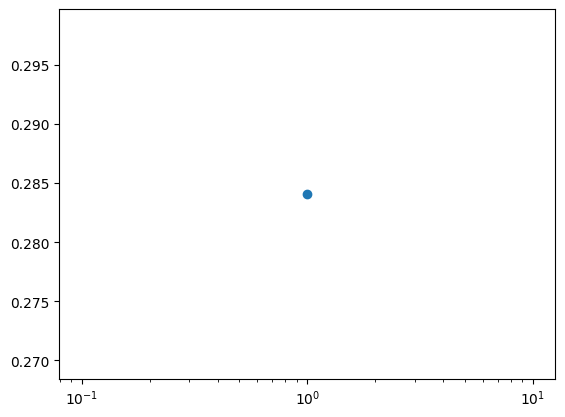

In [ ]:
import matplotlib.pyplot as plt

exps = np.linspace(-20, 0, 100)
exps = exps
xs = np.pow(10, exps)
print(xs)
ys = s_inv(xs)
print(ys)
plt.scatter(xs, ys)
plt.xscale("log")
plt.show()

In [ ]:
for s1, s2, s3, exp in product([+1, -1], [+1, -1], [+1, -1], [0, 1, oo]):
    get_soln(1, 1, 1, oo)(-1e-55 * I)

In [ ]:
from sympy import I, exp, pi

expr = get_soln(1, 1, 1, oo)(z)
(expr.subs(z, -0.000000001 - 0.00000000 * I) * exp(-I * pi / 5)).evalf()

0.104483432712088 - 0.321566940765553*I

In [ ]:
c = _
s = symbols("s")
solve(c / s ** (1 / 5) - 0.284079043840412, s)

[]

In [ ]:
alpha = np.arccos(1 / 2 / np.sin(np.pi / 5))
n3 = (
    2
    / np.sqrt(3)
    * np.array(
        [
            -np.sin(alpha) * np.cos(np.pi / 5),
            np.sin(alpha) * np.sin(np.pi / 5),
            np.cos(alpha) * np.cos(np.pi / 5),
        ]
    )
)
n2 = np.array([-np.sin(alpha), 0, np.cos(alpha)])
dp = np.dot(n2, n3)
print(dp)
cp = np.cross(n2, n3)
theta = np.arccos(dp)
yp = cp / np.sin(theta)
# xp = (n2 - dp*n3)/np.sqrt(2*(1-dp**2))
np.linalg.norm(yp), np.linalg.norm(n3), np.linalg.norm(n2)

0.9341723589627158


(np.float64(1.000000000000001),
 np.float64(1.0000000000000002),
 np.float64(1.0))

In [ ]:
xp = np.cross(yp, n3)
np.linalg.norm(yp)

np.float64(1.000000000000001)

In [259]:
xp, yp, n3

(array([ 0.18759247,  0.93417236, -0.303531  ]),
 array([-0.85065081,  0.        , -0.52573111]),
 array([-0.49112347,  0.35682209,  0.79465447]))

In [260]:
O = np.vstack((xp, yp, n3))
O

array([[ 0.18759247,  0.93417236, -0.303531  ],
       [-0.85065081,  0.        , -0.52573111],
       [-0.49112347,  0.35682209,  0.79465447]])

In [261]:
zp = O @ np.array([0, 0, 1])
zp

array([-0.303531  , -0.52573111,  0.79465447])

In [262]:
zp = -zp
zpz = (zp[0] + I * zp[1]) / (1 - zp[2])
zpz

0.169130606358858 + 0.292942803328475*I

In [265]:
(zpz * exp(-I * pi / 3)).evalf()

0.338261212717717 - 6.29921462214078e-17*I

In [266]:
n2p = O @ n2
n2p = -n2p
n2pz = (n2p[0] + I * n2p[1]) / (1 - n2p[2])
n2pz

0.184483088138253 - 2.87002091483864e-17*I

In [264]:
O @ n3, O @ n2

(array([5.55111512e-17, 5.55111512e-17, 1.00000000e+00]),
 array([-3.56822090e-01,  5.55111512e-17,  9.34172359e-01]))

In [ ]:
-n3p[0] / (1 + n3p[2])

np.float64(0.1252004517810262)

In [ ]:
(1 + np.sqrt(5)) / 2 / np.sqrt(3)

np.float64(0.9341723589627158)

In [312]:
u, v, z, z_n = symbols("u v z z_n")

f = u * v * (u**10 + 11 * u**5 * v**5 - v**10)
H = (
    u**30
    + 522 * (u**25 * v**5 - u**5 * v**25)
    - 10005 * (u**20 * v**10 - u**10 * v**20)
    + v**30
)
F = u**20 - 228 * (u**15 * v**5 - u**5 * v**15) + 494 * u**10 * v**10 + v**20

In [323]:
from utils import z_simp

num = z_simp((F**3).subs(u, z * z_n + 1).subs(v, z - z_n).expand(), z_n)
num

15693023681640625*z**60 - 10734028198242187500*z**55 + 2470615490295410156250*z**50 - 196593726450805664062500*z**45 + 1215589382426605224609375*z**40 - 2050907831725341796875000*z**35 - 521195509844848632812500*z**30 + 2050907831725341796875000*z**25 + 1215589382426605224609375*z**20 + 196593726450805664062500*z**15 + 2470615490295410156250*z**10 + 10734028198242187500*z**5 + z_n*(-25391845703125000*z**60 + 17368022460937500000*z**55 - 3997539836425781250000*z**50 + 318095331372070312500000*z**45 - 1966864937127685546875000*z**40 + 3318438579521484375000000*z**35 + 843312049711914062500000*z**30 - 3318438579521484375000000*z**25 - 1966864937127685546875000*z**20 - 318095331372070312500000*z**15 - 3997539836425781250000*z**10 - 17368022460937500000*z**5 - 25391845703125000) + 15693023681640625

In [315]:
_ / 15693023681640625

z**60 - 684*z**55 + 157434*z**50 - 12527460*z**45 + 77460495*z**40 - 130689144*z**35 - 33211924*z**30 + 130689144*z**25 + 77460495*z**20 + 12527460*z**15 + 157434*z**10 + 684*z**5 + z_n*(-25391845703125000*z**60 + 17368022460937500000*z**55 - 3997539836425781250000*z**50 + 318095331372070312500000*z**45 - 1966864937127685546875000*z**40 + 3318438579521484375000000*z**35 + 843312049711914062500000*z**30 - 3318438579521484375000000*z**25 - 1966864937127685546875000*z**20 - 318095331372070312500000*z**15 - 3997539836425781250000*z**10 - 17368022460937500000*z**5 - 25391845703125000)/15693023681640625 + 1

In [ ]:
denom = z_simp((f**5).subs(u, z * z_n + 1).subs(v, z - z_n).expand(), z_n)
denom

15693023681640625*z**55 + 863116302490234375*z**50 + 18910093536376953125*z**45 + 205421679992675781250*z**40 + 1091999052886962890625*z**35 + 2114807564361572265625*z**30 - 1091999052886962890625*z**25 + 205421679992675781250*z**20 - 18910093536376953125*z**15 + 863116302490234375*z**10 - 15693023681640625*z**5 + z_n*(-25391845703125000*z**55 - 1396551513671875000*z**50 - 30597174072265625000*z**45 - 332379260253906250000*z**40 - 1766891583251953125000*z**35 - 3421830518798828125000*z**30 + 1766891583251953125000*z**25 - 332379260253906250000*z**20 + 30597174072265625000*z**15 - 1396551513671875000*z**10 + 25391845703125000*z**5)

In [ ]:
z_simp(denom * denom.subs(z_n, -1 - z_n), z_n)

931322574615478515625*z**10*(z**2 + z - 1)**10*(z**4 - 3*z**3 + 4*z**2 - 2*z + 1)**10*(z**4 + 2*z**3 + 4*z**2 + 3*z + 1)**10

In [ ]:
(f**5).subs(u, z).subs(v, 1).factor()

z**5*(z**2 + z - 1)**5*(z**4 - 3*z**3 + 4*z**2 - 2*z + 1)**5*(z**4 + 2*z**3 + 4*z**2 + 3*z + 1)**5

In [331]:
z_simp(num * denom.subs(z_n, -1 - z_n), z_n)

931322574615478515625*z**115 - 585801899433135986328125*z**110 + 112707726657390594482421875*z**105 - 4358328878879547119140625000*z**100 - 401144670322537422180175781250*z**95 - 8337759913876652717590332031250*z**90 - 62401286315172910690307617187500*z**85 + 4024955218657851219177246093750*z**80 + 1813690744242630898952484130859375*z**75 + 1811835736907087266445159912109375*z**70 - 22046607219167985022068023681640625*z**65 + 14687385724041610956192016601562500*z**60 + 22046607219167985022068023681640625*z**55 + 1811835736907087266445159912109375*z**50 - 1813690744242630898952484130859375*z**45 + 4024955218657851219177246093750*z**40 + 62401286315172910690307617187500*z**35 - 8337759913876652717590332031250*z**30 + 401144670322537422180175781250*z**25 - 4358328878879547119140625000*z**20 - 112707726657390594482421875*z**15 - 585801899433135986328125*z**10 - 931322574615478515625*z**5

In [ ]:
(931322574615478515625 * F**3 * f**5).subs(u, z).subs(v, 1).expand()

931322574615478515625*z**115 - 585801899433135986328125*z**110 + 112707726657390594482421875*z**105 - 4358328878879547119140625000*z**100 - 401144670322537422180175781250*z**95 - 8337759913876652717590332031250*z**90 - 62401286315172910690307617187500*z**85 + 4024955218657851219177246093750*z**80 + 1813690744242630898952484130859375*z**75 + 1811835736907087266445159912109375*z**70 - 22046607219167985022068023681640625*z**65 + 14687385724041610956192016601562500*z**60 + 22046607219167985022068023681640625*z**55 + 1811835736907087266445159912109375*z**50 - 1813690744242630898952484130859375*z**45 + 4024955218657851219177246093750*z**40 + 62401286315172910690307617187500*z**35 - 8337759913876652717590332031250*z**30 + 401144670322537422180175781250*z**25 - 4358328878879547119140625000*z**20 - 112707726657390594482421875*z**15 - 585801899433135986328125*z**10 - 931322574615478515625*z**5

In [ ]:
z_simp(num * denom.subs(z_n, -1 - z_n), z_n).expand().equals(
    (931322574615478515625 * F**3 * f**5).subs(u, z).subs(v, 1).expand()
)

True

In [317]:
_ / 15693023681640625

z**55 + 55*z**50 + 1205*z**45 + 13090*z**40 + 69585*z**35 + 134761*z**30 - 69585*z**25 + 13090*z**20 - 1205*z**15 + 55*z**10 - z**5 + z_n*(-25391845703125000*z**55 - 1396551513671875000*z**50 - 30597174072265625000*z**45 - 332379260253906250000*z**40 - 1766891583251953125000*z**35 - 3421830518798828125000*z**30 + 1766891583251953125000*z**25 - 332379260253906250000*z**20 + 30597174072265625000*z**15 - 1396551513671875000*z**10 + 25391845703125000*z**5)/15693023681640625

In [318]:
25391845703125000 / 15693023681640625

1.6180339887482036